In [2]:
#imports 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [3]:
# load in data and see what we have 
train_data = pd.read_csv('../data/sign_mnist_train.csv')
test_data = pd.read_csv('../data/sign_mnist_test.csv')

In [4]:
#check that it all loaded in and stuff
print(f"\nTraining data shape: {train_data.shape}")
print(f"Test data shape: {test_data.shape}")
print(f"\nTotal training images: {len(train_data):,}")
print(f"Total test images: {len(test_data):,}")
print(train_data.head())


Training data shape: (27455, 785)
Test data shape: (7172, 785)

Total training images: 27,455
Total test images: 7,172
   label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      3     107     118     127     134     139     143     146     150   
1      6     155     157     156     156     156     157     156     158   
2      2     187     188     188     187     187     186     187     188   
3      2     211     211     212     212     211     210     211     210   
4     13     164     167     170     172     176     179     180     184   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0     153  ...       207       207       207       207       206       206   
1     158  ...        69       149       128        87        94       163   
2     187  ...       202       201       200       199       198       199   
3     210  ...       235       234       233       231       230       226   
4     185  ...        92       10

Sample images from training data:



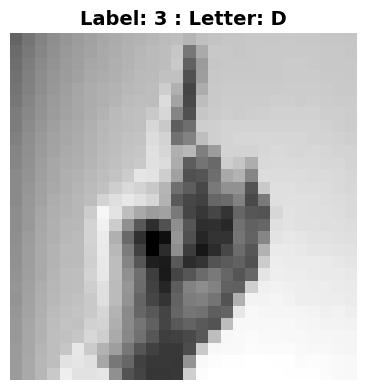

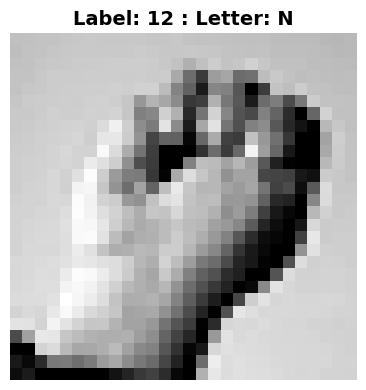

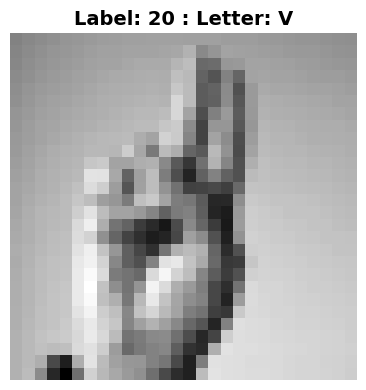

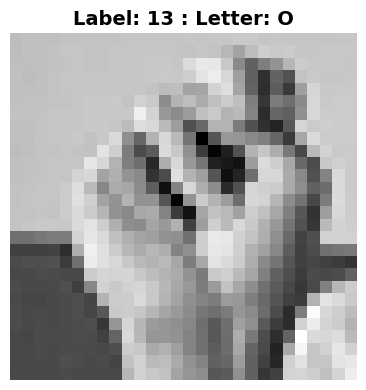

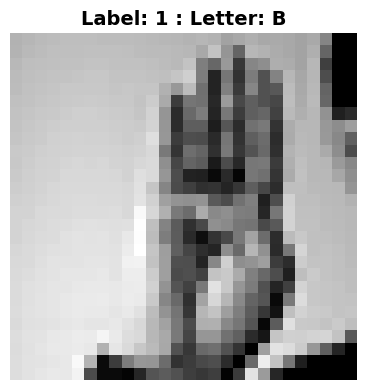

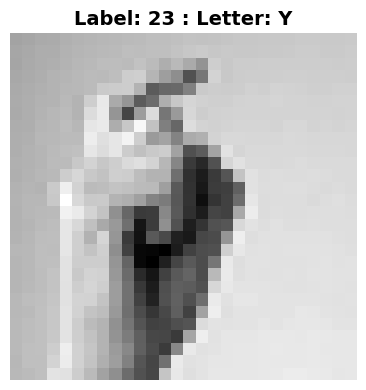

In [5]:
# Func to acc see the image
def show_sign_language_image(data, index):
    """Display a sign language image"""
    image_data = data.iloc[index]
    
    label = int(image_data['label'])

    pixels = image_data.drop('label').values
  
    image = pixels.reshape(28, 28)
    
    # visualize 
    plt.figure(figsize=(4, 4))
    plt.imshow(image, cmap='gray')
    
    #number to letter (0=A)
    letter_map = {0:'A', 1:'B', 2:'C', 3:'D', 4:'E', 5:'F', 6:'G', 7:'H', 8:'I',
                  9:'K', 10:'L', 11:'M', 12:'N', 13:'O', 14:'P', 15:'Q', 16:'R',
                  17:'S', 18:'T', 19:'U', 20:'V', 21:'W', 22:'X', 23:'Y'}
    
    letter = letter_map.get(label, '?')
    plt.title(f'Label: {label} : Letter: {letter}', fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# first 6 
print("Sample images from training data:\n")
for i in [0, 100, 500, 1000, 5000, 10000]:
    show_sign_language_image(train_data, i)

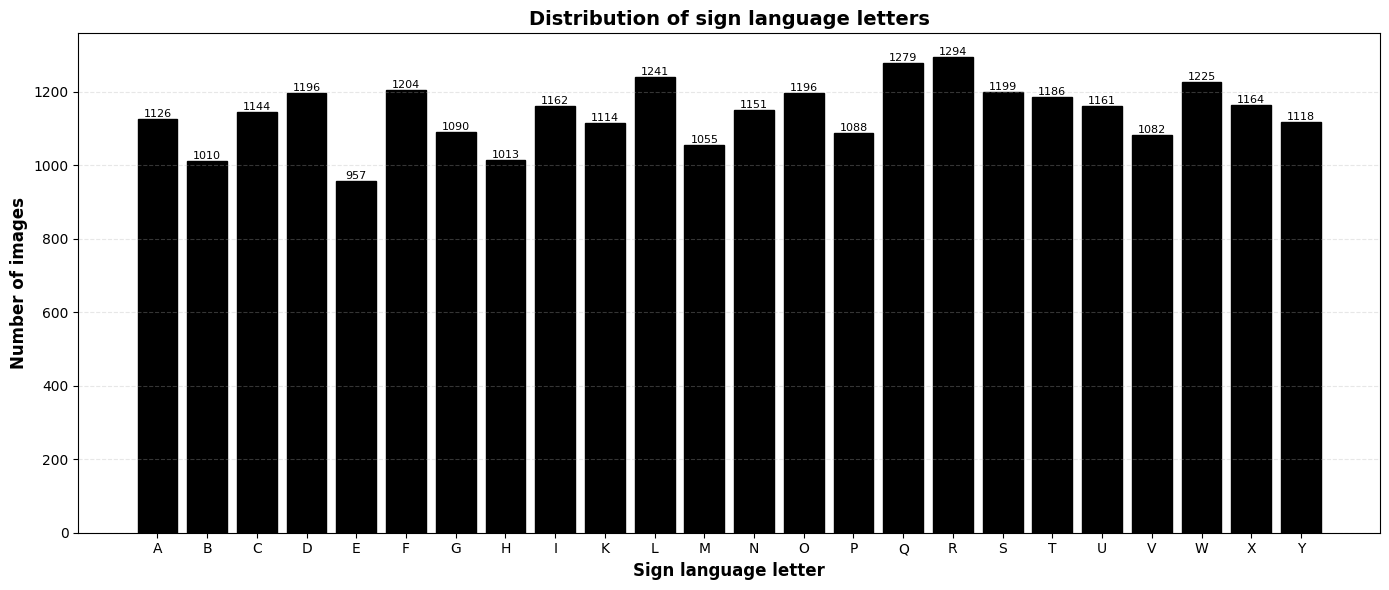

stats 

Total number of classes: 24
Average images per class: 1144
Min images in a class: 957
Max images in a class: 1294

Images per letter:
  A: 1,126 images
  B: 1,010 images
  C: 1,144 images
  D: 1,196 images
  E: 957 images
  F: 1,204 images
  G: 1,090 images
  H: 1,013 images
  I: 1,162 images
  K: 1,114 images
  L: 1,241 images
  M: 1,055 images
  N: 1,151 images
  O: 1,196 images
  P: 1,088 images
  Q: 1,279 images
  R: 1,294 images
  S: 1,199 images
  T: 1,186 images
  U: 1,161 images
  V: 1,082 images
  W: 1,225 images
  X: 1,164 images
  Y: 1,118 images


In [6]:
#data distribution checks 

#  how many of each letter we have
label_counts = train_data['label'].value_counts().sort_index()

# chart to visualize 
letters = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 
           'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 
           'S', 'T', 'U', 'V', 'W', 'X', 'Y']
plt.figure(figsize=(14, 6))
bars = plt.bar(range(len(label_counts)), label_counts.values, color='black', edgecolor='black')
plt.xlabel('Sign language letter', fontsize=12, fontweight='bold')
plt.ylabel('Number of images', fontsize=12, fontweight='bold')
plt.title('Distribution of sign language letters', fontsize=14, fontweight='bold')
plt.xticks(range(len(letters)), letters, fontsize=10)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()

#  value labels on top of bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom', fontsize=8)

plt.show()

# show stats
print("stats ")
print(f"\nTotal number of classes: {len(label_counts)}")
print(f"Average images per class: {label_counts.mean():.0f}")
print(f"Min images in a class: {label_counts.min()}")
print(f"Max images in a class: {label_counts.max()}")
print("\nImages per letter:")
for idx, (label, count) in enumerate(label_counts.items()):
    print(f"  {letters[idx]}: {count:,} images")

### results
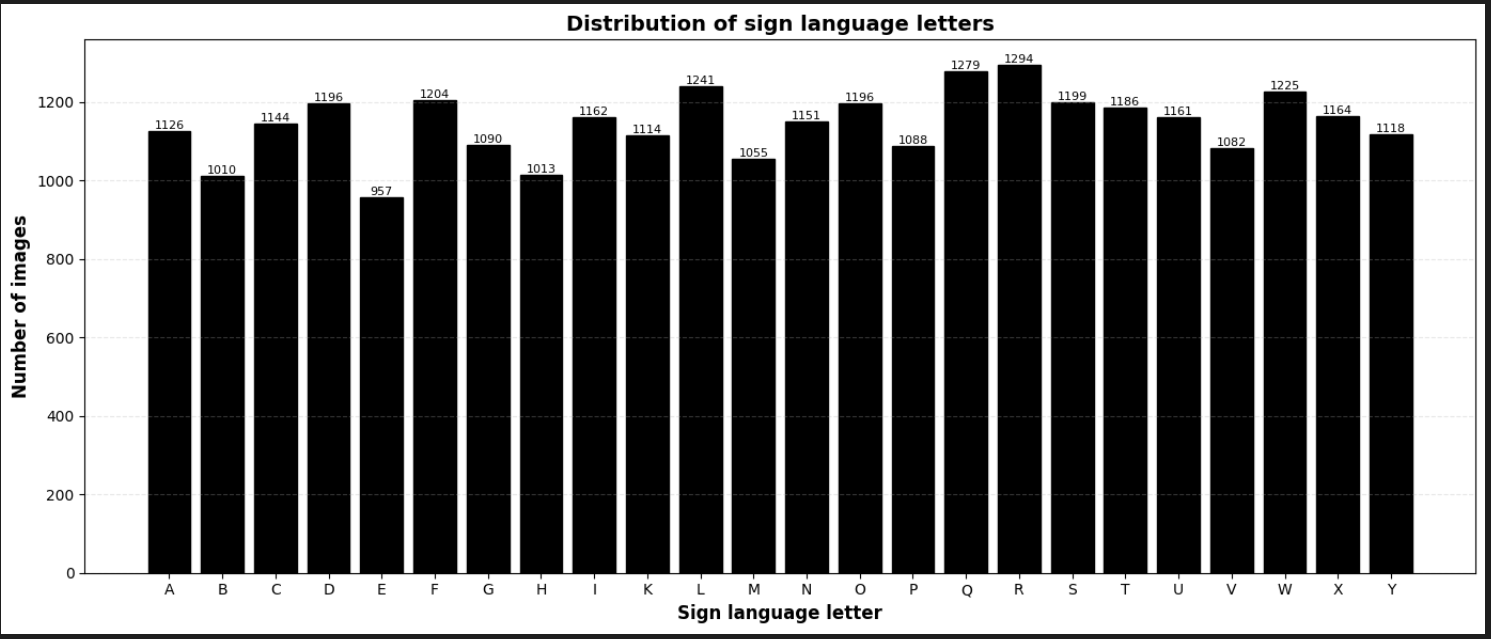

stats 

Total number of classes: 24
Average images per class: 1144
Min images in a class: 957
Max images in a class: 1294

Images per letter:
  A: 1,126 images
  B: 1,010 images
  C: 1,144 images
  D: 1,196 images
  E: 957 images
  F: 1,204 images
  G: 1,090 images
  H: 1,013 images
  I: 1,162 images
  K: 1,114 images
  L: 1,241 images
  M: 1,055 images
  N: 1,151 images
  O: 1,196 images
  P: 1,088 images
  Q: 1,279 images
  R: 1,294 images
...
  V: 1,082 images
  W: 1,225 images
  X: 1,164 images
  Y: 1,118 images

Data quality assesment 

1. check for missing values

In [7]:
# into boolean table
print("Training set missing values:", train_data.isnull().sum().sum())
print("Test set missing values:", test_data.isnull().sum().sum())

Training set missing values: 0
Test set missing values: 0


We have no null values in the training set and the test set.

2. check class balance 

In [8]:
#select the lable column, count how many times each unique value appears, sort by frequency
class_counts = train_data['label'].value_counts().sort_index()
# find which class has the lowest images (e.g. class A has the lowest)
print(f"Min images per class: {class_counts.min()}")
# find which class has the highest images (e.g. class B has the highest)
print(f"Max images per class: {class_counts.max()}")
#find the average number per class and round to 0 d.p to get a pretty number
print(f"Average per class: {class_counts.mean():.0f}")
# measure how spread out the values are (sd) to 1 dp for a pretty number
#the smaller the sd the more balanced the classes, the larger the sd the more spread out 
print(f"Standard deviation: {class_counts.std():.1f}")


Min images per class: 957
Max images per class: 1294
Average per class: 1144
Standard deviation: 83.8


### results:
 Min images per class: 957
 Max images per class: 1294
 Average per class: 1144
 Standard deviation: 83.8

### evaluation:
our smallest class has 957 images which is great, lots of data to work with
the difference between the mix and max is 337 / 1144 ≈ 29%, which is not great but its not catastrophic 
our sd is around 83.8 / 1144 ≈ 7.3% which is pretty low so we dont need heavy class weighting 

model bias should be low!


3. check pixel value ranges 

In [9]:
#we remove the lable column and leave only yhr pixel columns 
# so each column has one pixel intensity 
pixel_columns = [col for col in train_data.columns if col != 'label']
pixel_data = train_data[pixel_columns]
#we find the min and maz for  each column to get the global minimum pixel value in the dataset 
print(f"Minimum pixel value: {pixel_data.min().min()}")
print(f"Maximum pixel value: {pixel_data.max().max()}")
print(f"Mean pixel value: {pixel_data.mean().mean():.2f}")

Minimum pixel value: 0
Maximum pixel value: 255
Mean pixel value: 159.29


### results:
Minimum pixel value: 0
Maximum pixel value: 255
Mean pixel value: 159.29

### evaluation:
so the min and max values tell us that we have an 8 bit grayscale, each pizel value ranges from 0 to 225, theres no corruption present and we dont have any issues with it. standard image encoding.

now the more interesting part here is the mean pixel value, becasue if we consider 0 being black and 255 being white, then a mid gray value should be around 127, but we got 159 which is on the brighter side (towards white0\), so from that we can deduce that there probably is a light backround , hands are going to be darker than the backround and overall our images lean on the lighter side. 
this makes sense since traditionally ASL datasets are shot on lighter backroudns.

we should still normalize to improve gradient stbailty, convergence speed and training perfromance. 

4. verify all classes are present 

In [10]:
#first we get all our unique class lables present in the dataset 
unique_labels = sorted(train_data['label'].unique())
#then we check which lables from 0-23 are not presetn in the dataset 
expected_labels = list(range(24))  # 0-23 for A-Y (no J=9, no Z=25)
missing_labels = set(expected_labels) - set(unique_labels)
if missing_labels:
    print(f"Missing labels: {missing_labels}")
else:
    print(f"All 24 classes present")

print("Number of classes:", train_data['label'].nunique())


Missing labels: {9}
Number of classes: 24


### results
Missing labels: {9}
Number of classes: 24

### evaluation 
usually datasets for asl exclude J (9) and Z (25) because they include motion and we cannot demosntrate that statically 

5. summary of quality assesment 